In [1]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Set seaborn style for better visuals
sns.set_style("whitegrid")

In [5]:
# 1. Load the dataset
# Note: Make sure mtcars.csv is in your working directory
mt_df = pd.read_csv("mtcars.csv")

In [6]:
# 2. Basic inspection
print("First 5 rows:")
display(mt_df.head())

First 5 rows:


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [7]:
print("\nDataset Info:")
mt_df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


In [8]:
print("\nMissing Values:")
print(mt_df.isnull().sum())


Missing Values:
model    0
mpg      0
cyl      0
disp     0
hp       0
drat     0
wt       0
qsec     0
vs       0
am       0
gear     0
carb     0
dtype: int64


In [9]:
print("\nDescriptive Statistics:")
display(mt_df.describe().round(2))


Descriptive Statistics:


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00
mean,20.09,6.19,230.72,146.69,3.60,3.22,17.85,0.44,0.41,3.69,2.81
std,6.03,1.79,123.94,68.56,0.53,0.98,1.79,0.50,0.50,0.74,1.62
min,10.40,4.00,71.10,52.00,2.76,1.51,14.50,0.00,0.00,3.00,1.00
25%,15.42,4.00,120.82,96.50,3.08,2.58,16.89,0.00,0.00,3.00,2.00
50%,19.20,6.00,196.30,123.00,3.70,3.32,17.71,0.00,0.00,4.00,2.00
75%,22.80,8.00,326.00,180.00,3.92,3.61,18.90,1.00,1.00,4.00,4.00
max,33.90,8.00,472.00,335.00,4.93,5.42,22.90,1.00,1.00,5.00,8.00


In [12]:
# 3. Data Cleaning
# Remove 'model' column (not useful for numeric analysis)
mt_cleaned = mt_df.drop(['model'], axis=1)

In [13]:
print("\nCleaned dataset - first 5 rows:")
display(mt_cleaned.head())


Cleaned dataset - first 5 rows:


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [14]:
# 4. Create mpg categories for better grouping visualization
mt_cleaned["mpg_group"] = pd.cut(
    mt_cleaned["mpg"],
    bins=[0, 15, 25, 100],
    labels=["Low (≤15)", "Medium (15-25)", "High (>25)"]
)

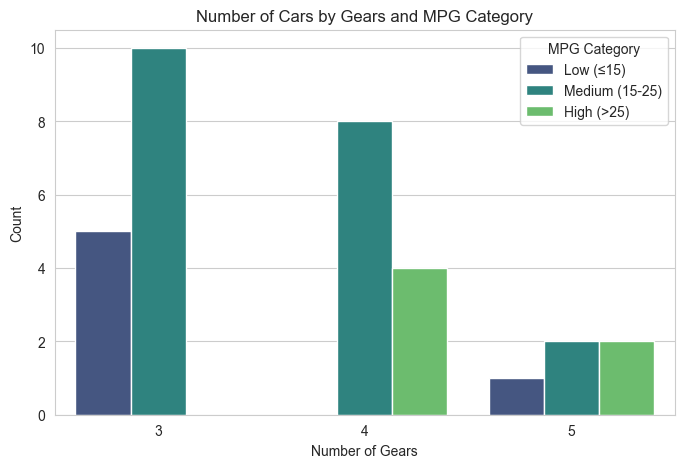

In [15]:
# 5. Visualization 1: Count of cars by number of gears and mpg category
plt.figure(figsize=(8, 5))
sns.countplot(
    data=mt_cleaned,
    x="gear",
    hue="mpg_group",
    palette="viridis"
)
plt.title("Number of Cars by Gears and MPG Category")
plt.xlabel("Number of Gears")
plt.ylabel("Count")
plt.legend(title="MPG Category")
plt.show()


Count of cars by gear and mpg_group:


C:\Users\jeeva\AppData\Local\Temp\ipykernel_21116\2405901767.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(mt_cleaned.groupby(["gear", "mpg_group"]).size().unstack(fill_value=0))


mpg_group,Low (≤15),Medium (15-25),High (>25)
gear,,,
3,5,10,0
4,0,8,4
5,1,2,2


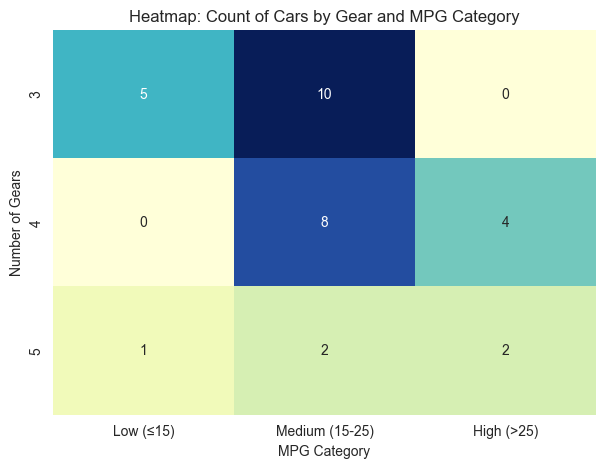

In [16]:
# Alternative: Groupby summary table
print("\nCount of cars by gear and mpg_group:")
display(mt_cleaned.groupby(["gear", "mpg_group"]).size().unstack(fill_value=0))

# 6. Visualization 2: Heatmap – Gear vs MPG category counts
gear_mpg = pd.crosstab(mt_cleaned["gear"], mt_cleaned["mpg_group"])
plt.figure(figsize=(7, 5))
sns.heatmap(gear_mpg, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("Heatmap: Count of Cars by Gear and MPG Category")
plt.xlabel("MPG Category")
plt.ylabel("Number of Gears")
plt.show()

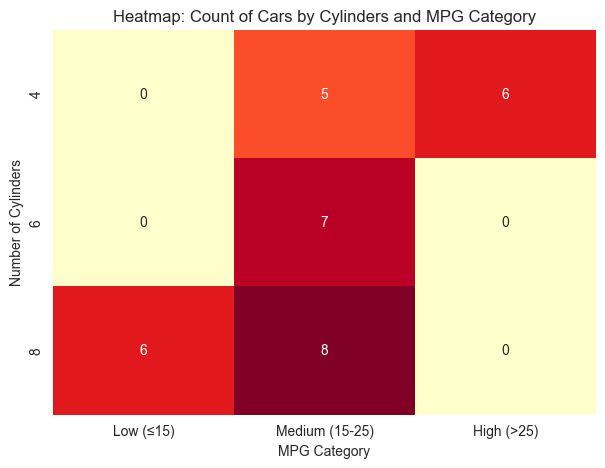

In [17]:
# 7. Visualization 3: Heatmap – Cylinders vs MPG category counts
cyl_mpg = pd.crosstab(mt_cleaned["cyl"], mt_cleaned["mpg_group"])
plt.figure(figsize=(7, 5))
sns.heatmap(cyl_mpg, annot=True, fmt="d", cmap="YlOrRd", cbar=False)
plt.title("Heatmap: Count of Cars by Cylinders and MPG Category")
plt.xlabel("MPG Category")
plt.ylabel("Number of Cylinders")
plt.show()

C:\Users\jeeva\AppData\Local\Temp\ipykernel_21116\1882941332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


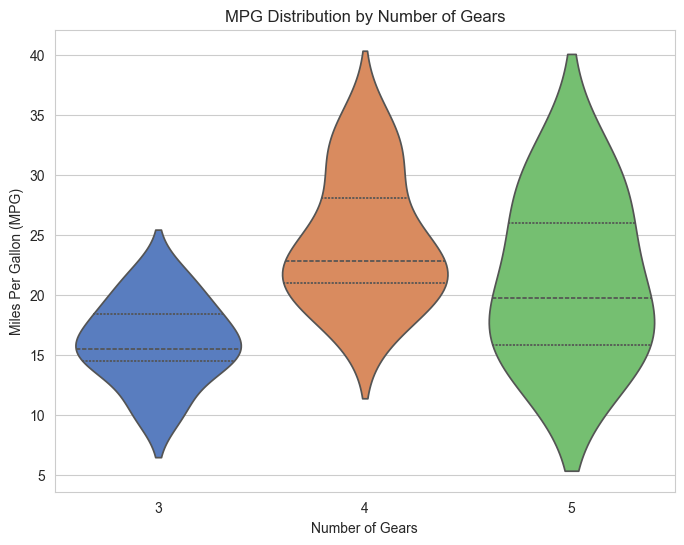

In [18]:
# 8. Visualization 4: Violin plot – MPG distribution by number of gears
plt.figure(figsize=(8, 6))
sns.violinplot(
    x="gear",
    y="mpg",
    data=mt_cleaned,
    palette="muted",
    inner="quartile"
)
plt.title("MPG Distribution by Number of Gears")
plt.xlabel("Number of Gears")
plt.ylabel("Miles Per Gallon (MPG)")
plt.show()

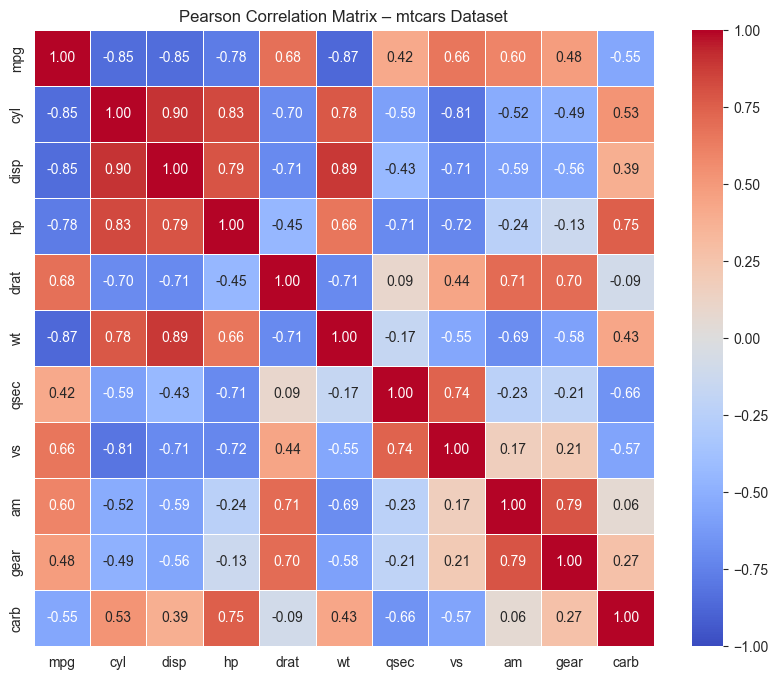

In [19]:
# 9. Visualization 5: Correlation Heatmap (only numeric columns)
numeric_df = mt_cleaned.select_dtypes(include="number")
corr_matrix = numeric_df.corr(method="pearson").round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Pearson Correlation Matrix – mtcars Dataset")
plt.show()

In [1]:



# 7. Visualization 3: Heatmap – Cylinders vs MPG category counts
cyl_mpg = pd.crosstab(mt_cleaned["cyl"], mt_cleaned["mpg_group"])
plt.figure(figsize=(7, 5))
sns.heatmap(cyl_mpg, annot=True, fmt="d", cmap="YlOrRd", cbar=False)
plt.title("Heatmap: Count of Cars by Cylinders and MPG Category")
plt.xlabel("MPG Category")
plt.ylabel("Number of Cylinders")
plt.show()

# 8. Visualization 4: Violin plot – MPG distribution by number of gears
plt.figure(figsize=(8, 6))
sns.violinplot(
    x="gear",
    y="mpg",
    data=mt_cleaned,
    palette="muted",
    inner="quartile"
)
plt.title("MPG Distribution by Number of Gears")
plt.xlabel("Number of Gears")
plt.ylabel("Miles Per Gallon (MPG)")
plt.show()

# 9. Visualization 5: Correlation Heatmap (only numeric columns)
numeric_df = mt_cleaned.select_dtypes(include="number")
corr_matrix = numeric_df.corr(method="pearson").round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Pearson Correlation Matrix – mtcars Dataset")
plt.show()

NameError: name 'pd' is not defined